In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load Dataset (bitcoin_price.csv)
dframe = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/bitcoin_price.csv', index_col='Date', parse_dates=True)
dframe

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100
...,...,...,...,...,...,...
2023-12-26,43599.847656,43603.175781,41676.488281,42520.402344,42520.402344,30026850982
2023-12-27,42518.468750,43683.160156,42167.582031,43442.855469,43442.855469,25260941032
2023-12-28,43468.199219,43804.781250,42318.550781,42627.855469,42627.855469,22992093014


In [ ]:
# Load Dataset (airline_passengers.csv)
dataf = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/airline_passengers.csv', index_col='Month', parse_dates=True)
dataf

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [ ]:
# Question 1
# What is the final expanded mean 'Close' price of bitcoin with 30 day window?
dframe['Close'].expanding(30).mean().iloc[-1]

14574.914414459805

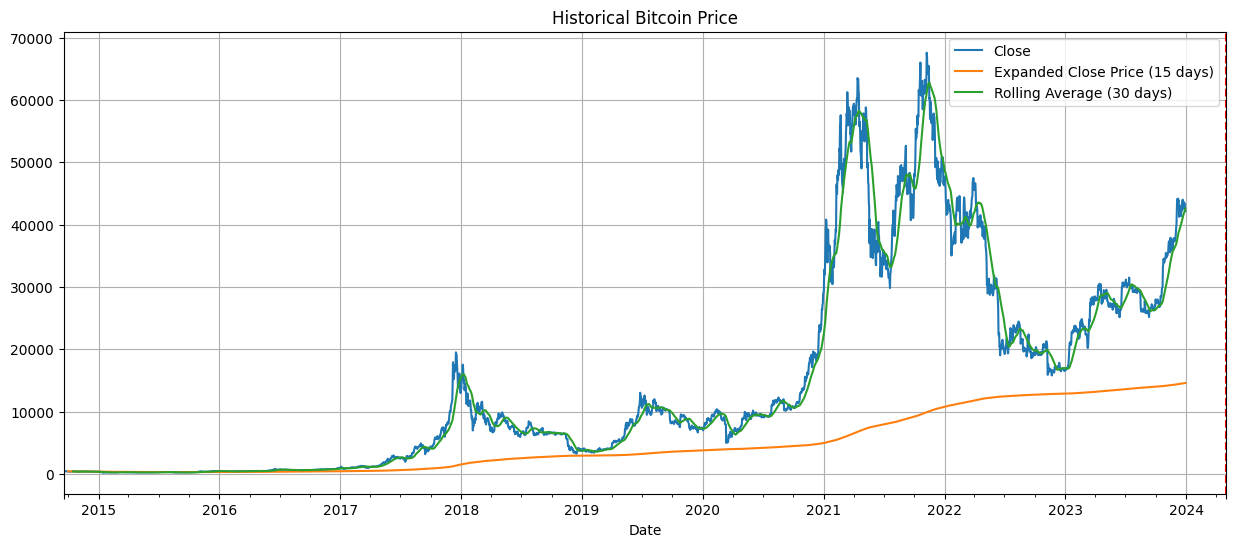

In [ ]:
# Question 2
# Project the graph below with (15,6)

dframe['Expanded Close Price (15 days)'] = dframe['Close'].expanding(min_periods=15).mean()
dframe['Rolling Average (30 days)'] = dframe['Close'].rolling(window=30).mean()
dframe[['Close','Expanded Close Price (15 days)','Rolling Average (30 days)']].plot(figsize=(15,6)).autoscale(axis='x',tight=True);
plt.grid(True)
plt.title('Historical Bitcoin Price')
plt.axvline(x=pd.to_datetime('2024-05-01'), color='red', linestyle='--')
plt.show()


In [ ]:
# Question 3
# Based on the graph (Question NO.2) above, what can you generalize about bitcoin prices?

# Answer: Bitcoin prices show volatility but a general upward trend over time.  The rolling average smooths out short-term fluctuations, revealing the long-term growth.


In [ ]:
# Question 4
# What is the highest and lowest Bitcoin 'Close' Prices from 2021 to 2023 only based on data?
# Answer: Highest () / Lowest ()
highest_price = dframe.loc['2021':'2023','Close'].max()
lowest_price = dframe.loc['2021':'2023','Close'].min()
print(f"Highest ({highest_price}) / Lowest ({lowest_price})")

Highest (67566.828125) / Lowest (15787.2841796875)


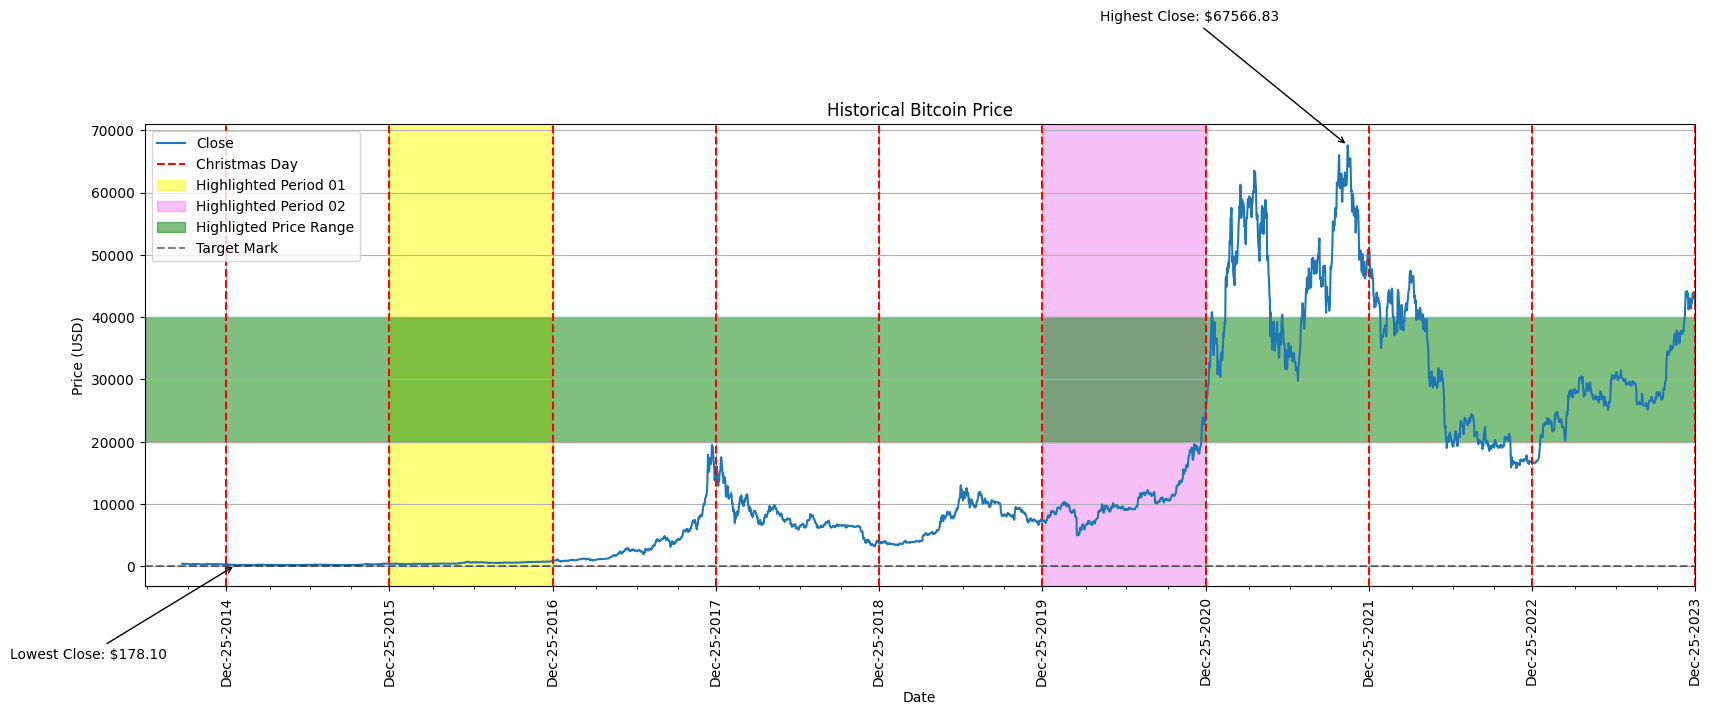

In [ ]:
# Question 5
# Project the graph below with (20,6) size colors should be similar but not exact
# Chect the date formatting below
import matplotlib.dates as mdates

important_dates = pd.to_datetime(['2014-12-25', '2015-12-25', '2016-12-25','2017-12-25', '2018-12-25', '2019-12-25','2020-12-25', '2021-12-25', '2022-12-25', '2023-12-25']) # 4th of JULYs
peak_close_date = dframe['Close'].idxmax()
peak_close_value = dframe['Close'].max()
lowest_close_date = dframe['Close'].idxmin()
lowest_close_value = dframe['Close'].min()
# Assuming your DataFrame is named 'data_bit' and has 'Date' as index and 'Close' as a column
ax = dframe['Close'].plot(xlim = ['2014-06-25', '2023-12-25'], figsize = (20,6)) # Line Graph with Limits
ax.xaxis.set_major_locator(dates.YearLocator(base = 1, month = 12, day = 25)) # show every year, 4th of July each year on x-axis
ax.xaxis.set_major_formatter(dates.DateFormatter('%b-%d-%Y')) # Format of Dates on x-axis

for day in important_dates:
    ax.axvline(day, color = 'red', linestyle = '--', label = 'Christmas Day' if day == important_dates[0] else "") # iterate every 4th of July for each year (vertical lines)
# Annotate the highest 'Close' price
ax.annotate(f'Highest Close: ${peak_close_value:.2f}', xy = (peak_close_date, peak_close_value),
            xytext=(peak_close_date - pd.DateOffset(months = 5), peak_close_value + 20000),
            arrowprops=dict(facecolor='black', arrowstyle='->'),
            horizontalalignment='right')

ax.annotate(f'Lowest Close: ${lowest_close_value:.2f}', xy = (lowest_close_date, lowest_close_value),
            xytext=(lowest_close_date - pd.DateOffset(months = 5), lowest_close_value - 15000),
            arrowprops=dict(facecolor='black', arrowstyle='->'),
            horizontalalignment='right')
ax.axvspan('2015-12-25', '2016-12-25', color='yellow', alpha = 0.5, label = 'Highlighted Period 01') # Vertical Span
ax.axvspan('2019-12-25', '2020-12-25', color='violet', alpha = 0.5, label = 'Highlighted Period 02') # Vertical Span
ax.axhspan(20000, 40000, color = 'green', alpha = 0.5, label = 'Highligted Price Range') # Horizontal Span
ax.axhline(70, color = 'black', alpha = 0.5, label = 'Target Mark', linestyle = '--') # Horizontal Line
ax.grid()
ax.legend()
plt.title("Historical Bitcoin Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend(loc= 'upper left')
plt.xticks(rotation=90)
plt.show()


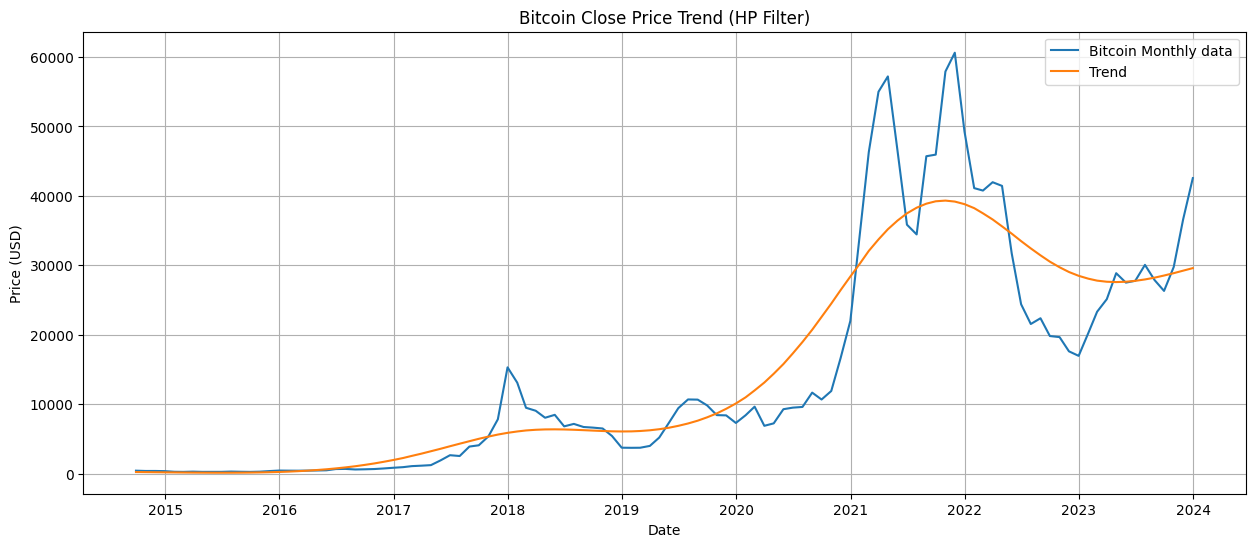

In [ ]:
# Question 6
# Using HP- Filter resample to monthly mean, what is the trend of bitcoin close pricing?
#Project the appropriate graph  to support your answer

from statsmodels.tsa.filters.hp_filter import hpfilter

# Resample to monthly mean
monthly_data = dframe['Close'].resample('ME').mean()

# Apply HP filter
cycle, trend = hpfilter(monthly_data, lamb=1600)

# Plot the results
plt.figure(figsize=(15, 6))
plt.plot(monthly_data, label='Bitcoin Monthly data')
plt.plot(trend, label='Trend')
plt.title('Bitcoin Close Price Trend (HP Filter)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()


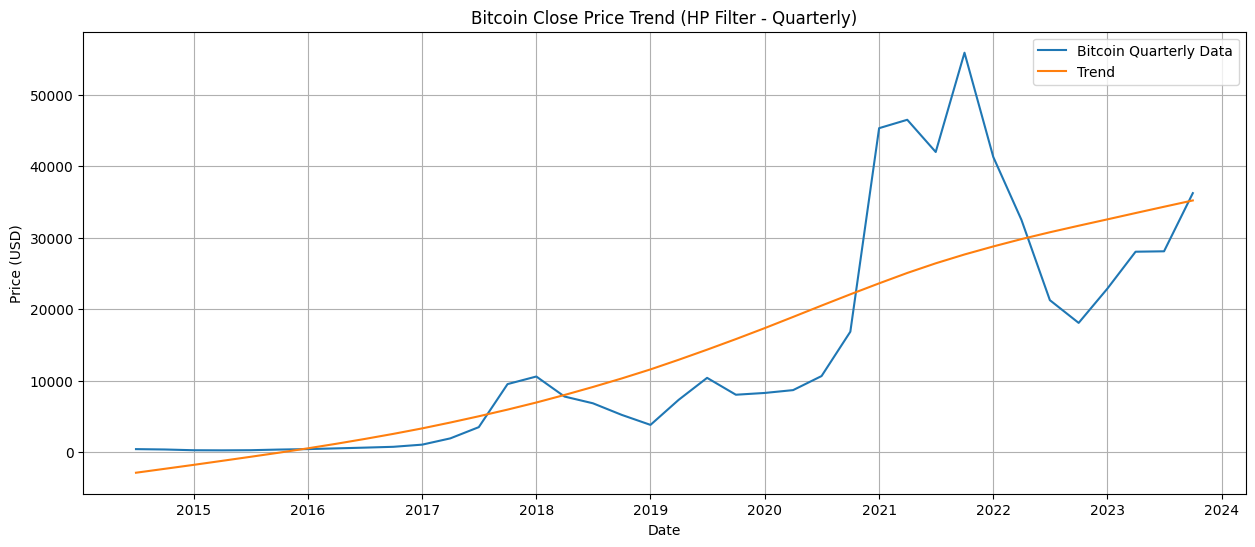

In [ ]:
# Question 7
# Using HP- Filter resample to quarterly mean, what is the trend of bitcoin close pricing?
# Project the appropriate graph  to support your answer

# Resample to quarterly mean
quarterly_data = dframe['Close'].resample('QS').mean()

# Apply HP filter
cycle, trend = hpfilter(quarterly_data, lamb=1600)

# Plot the results
plt.figure(figsize=(15, 6))
plt.plot(quarterly_data, label='Bitcoin Quarterly Data')
plt.plot(trend, label='Trend')
plt.title('Bitcoin Close Price Trend (HP Filter - Quarterly)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()



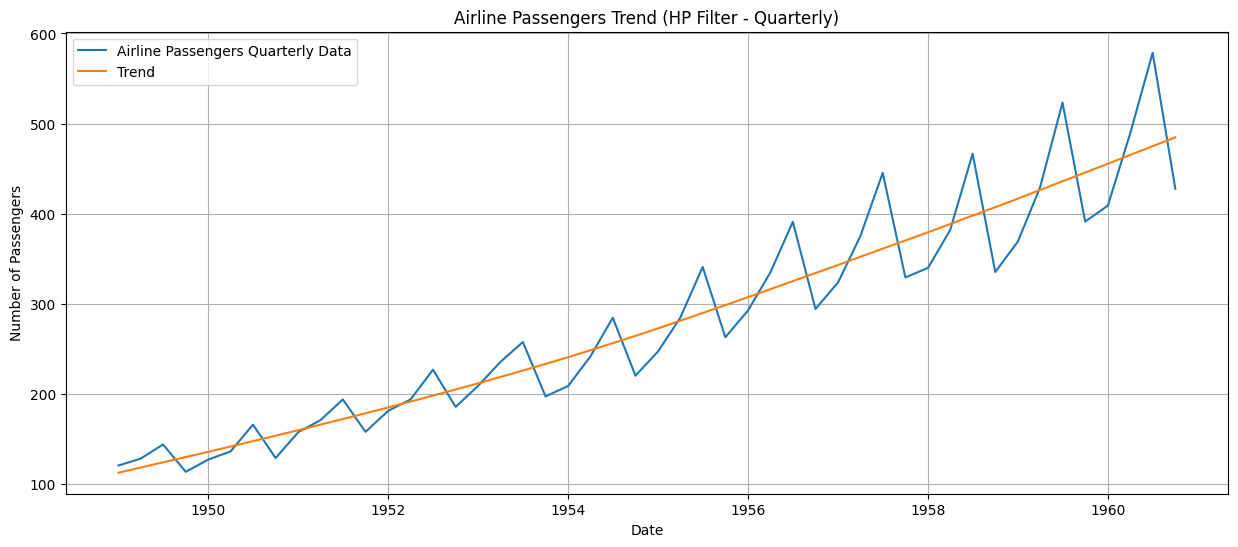

In [ ]:
# Question 8
# Using HP- Filter resample to quarterly mean, what is the trend of Airline Passengers?
#Project the appropriate graph  to support your answer from the airline

# Resample to quarterly mean
quarterly_data = dataf['Thousands of Passengers'].resample('QS').mean()

# Apply HP filter
cycle, trend = hpfilter(quarterly_data, lamb=1600)

# Plot the results
plt.figure(figsize=(15, 6))
plt.plot(quarterly_data, label='Airline Passengers Quarterly Data')
plt.plot(trend, label='Trend')
plt.title('Airline Passengers Trend (HP Filter - Quarterly)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()


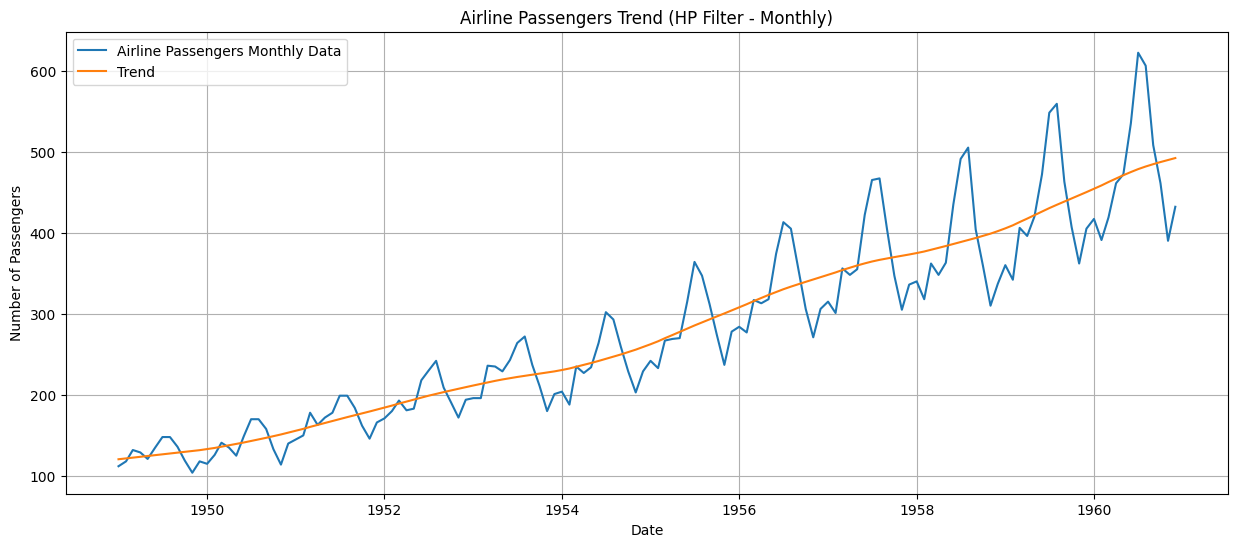

In [ ]:
# Question 9
# Using HP- Filter resample to monthly mean, what is the trend of Airline Passengers?
# Project the appropriate graph  to support your answer

# Resample to monthly mean
monthly_data = dataf['Thousands of Passengers'].resample('MS').mean()

# Apply HP filter
cycle, trend = hpfilter(monthly_data, lamb=1600)

# Plot the results
plt.figure(figsize=(15, 6))
plt.plot(monthly_data, label='Airline Passengers Monthly Data')
plt.plot(trend, label='Trend')
plt.title('Airline Passengers Trend (HP Filter - Monthly)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()


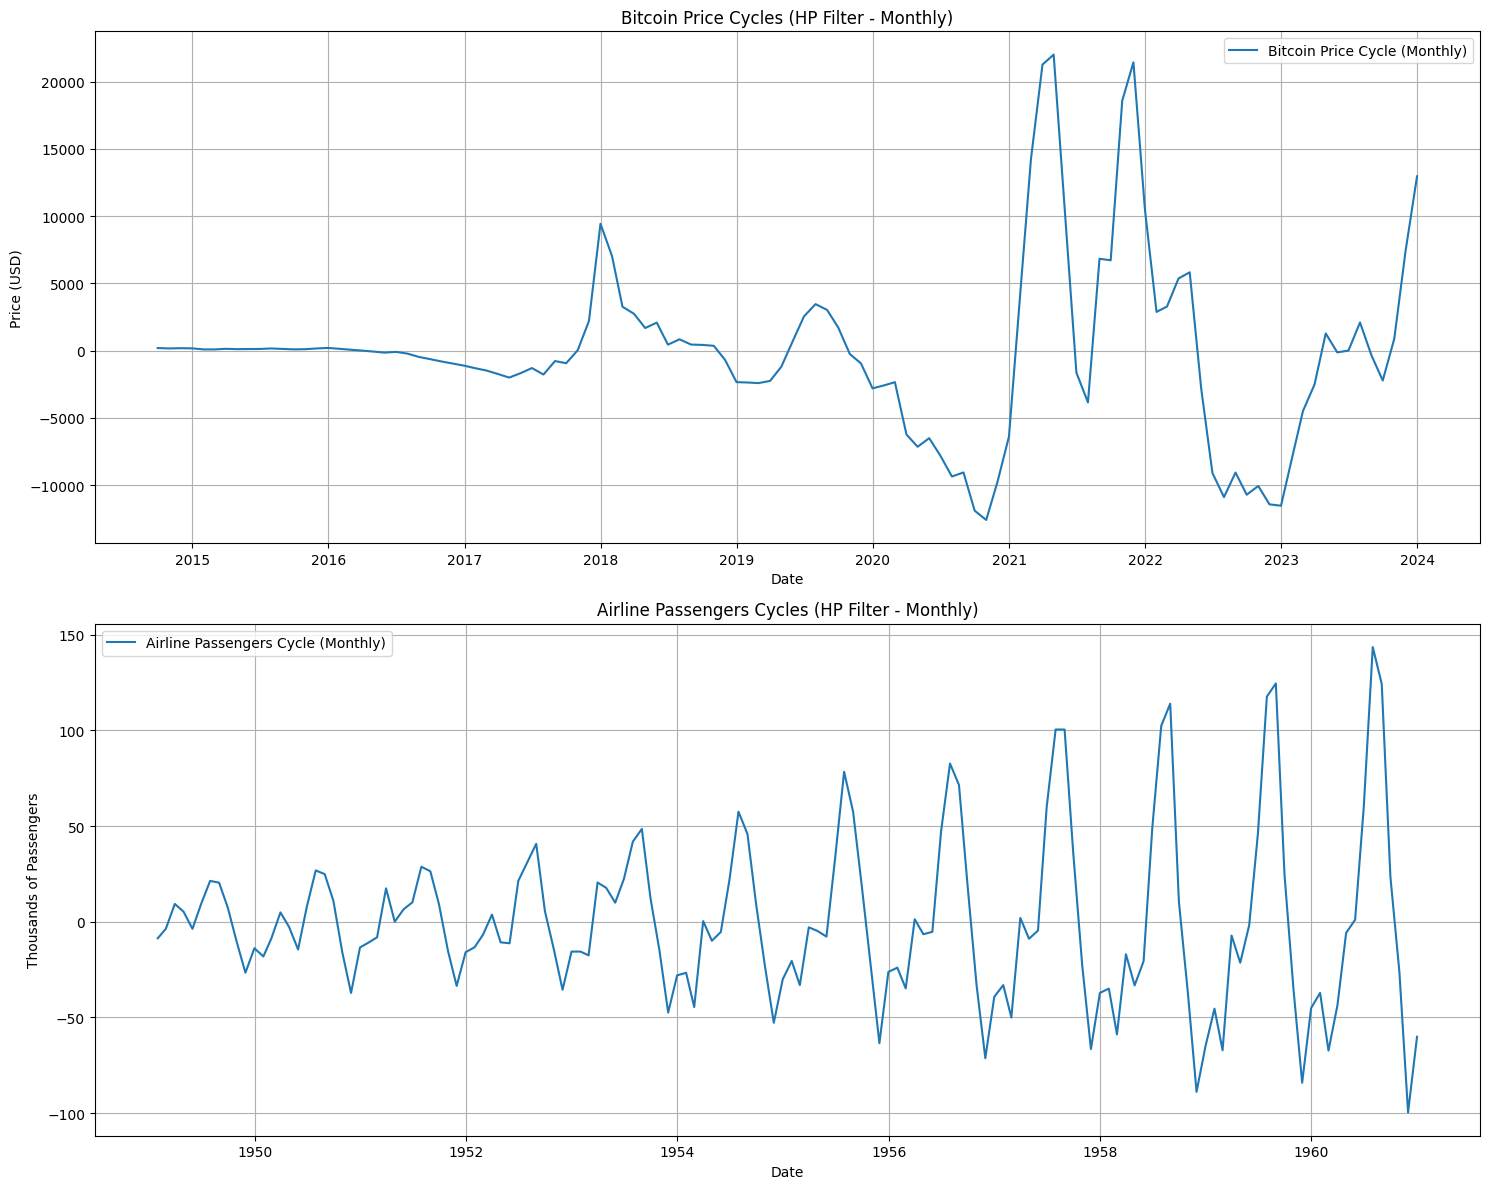

In [ ]:
# Question 10
# Using HP- Filter what can you infer about the cycles of Bitcoin Price and Airline Passengers, if resample to monthly mean?
# Project the appropriate graph  to support your answer
# Answer: Both Bitcoin price and airline passengers exhibit cyclical patterns when analyzed with the HP filter and monthly resampling.
# Bitcoin's price shows more volatile cycles superimposed on an upward trend, while airline passenger numbers display smoother, more regular cycles reflecting seasonal variations and broader economic influences.

# Resample Bitcoin data to monthly mean and apply HP filter
bitcoin_monthly = dframe['Close'].resample('ME').mean()
bitcoin_cycle, bitcoin_trend = hpfilter(bitcoin_monthly, lamb=1600)

# Resample Airline Passengers data to monthly mean and apply HP filter
airline_monthly = dataf['Thousands of Passengers'].resample('ME').mean()
airline_cycle, airline_trend = hpfilter(airline_monthly, lamb=1600)

# Plot the results
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Bitcoin plot
axes[0].plot(bitcoin_cycle, label='Bitcoin Price Cycle (Monthly)') # Plot only the cycle component
axes[0].set_title('Bitcoin Price Cycles (HP Filter - Monthly)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True)

# Airline Passengers plot
axes[1].plot(airline_cycle, label='Airline Passengers Cycle (Monthly)') # Plot only the cycle component
axes[1].set_title('Airline Passengers Cycles (HP Filter - Monthly)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Thousands of Passengers')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()